In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "../data/retail_sales_dataset.csv"
df = pd.read_csv(file_path)

# 1. Dataset Shape (Number of rows and columns)
print(f" Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

# 2. Column Data Types and General Info
print(f" Column Information:")
df.info()
print("\n")

# 3. Null Value Check
print(f"Missing Values Check: {df.isnull().sum()}")

# Display the first 5 rows to undestand the data structure
df.head()

 Dataset Shape: 120000 rows and 17 columns

 Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  str    
 1   transaction_date    120000 non-null  str    
 2   customer_id         120000 non-null  str    
 3   customer_gender     120000 non-null  str    
 4   customer_age_group  120000 non-null  str    
 5   customer_segment    120000 non-null  str    
 6   product_id          120000 non-null  str    
 7   product_name        120000 non-null  str    
 8   category            120000 non-null  str    
 9   brand               120000 non-null  str    
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


### Observations: Initial Data Inspection
* **Dataset Shape:** The dataset containing exactly 120,000 rows (transactions) and 17 columns (features).
* **Data Types:** The features represent a mix of categorical (`str`) and numerical data (`int64`, `float64`). 
* **Missing Values:** The dataset is perfectly clean in terms of missing data, with 0 null values across all columns.
* **Next Steps:** The `transaction_date` column is currently stored as a string. To perform the required time series analysis later, it must convert this column to a standard `datetime` format.


In [ ]:
# Descriptive Statistics

# Select only numerical columns for statistical analysis
numerical_df = df.select_dtypes(include=["int64", "float64"])

# Calculate Mean, Median (50%), and Standard Deviation
# the transpose (.T) to make it easier to read
stats_summary = numerical_df.agg(["mean", "median", "std"]).T

# Calculate Mode separately (mode() can return multiple rows, it pick the first)
mode_values = numerical_df.mode().iloc[0].rename("mode")

# Combine all statistics into a single DataFrame
final_statistics = pd.concat([stats_summary, mode_values], axis=1)

# Display the clean statistical summary
display(final_statistics)

,mean,median,std,mode
quantity,1.662908,1.00,1.014291,1.00
unit_price,240.621785,238.75,146.457057,95.79
discount_pct,5.496500,0.00,8.193257,0.00
sales_amount,377.975454,295.98,356.893357,128.40


### Observations: Descriptive Statistics
* **Purchase Quantity:** The median and mode for `quantity` are both exactly 1.00. This indicates that customers typically purchase a single item per transaction.
* **Unit Price:** The `unit_price` shows a symmetrical distribution, as the mean (240.62) and median (238.75) are remarkably close.
* **Discounts:** The median and mode for `discount_pct` are 0.00, revealing that the vast majority of purchases are made without any discount applied.
* **Sales Amount:** The `sales_amount` mean (377.98) is noticeably higher than its median (295.98), coupled with a high standard deviation (356.89). This indicates a right-skewed distribution, meaning that while most purchases are around 295, a few high-value transactions are driving the overall average up.


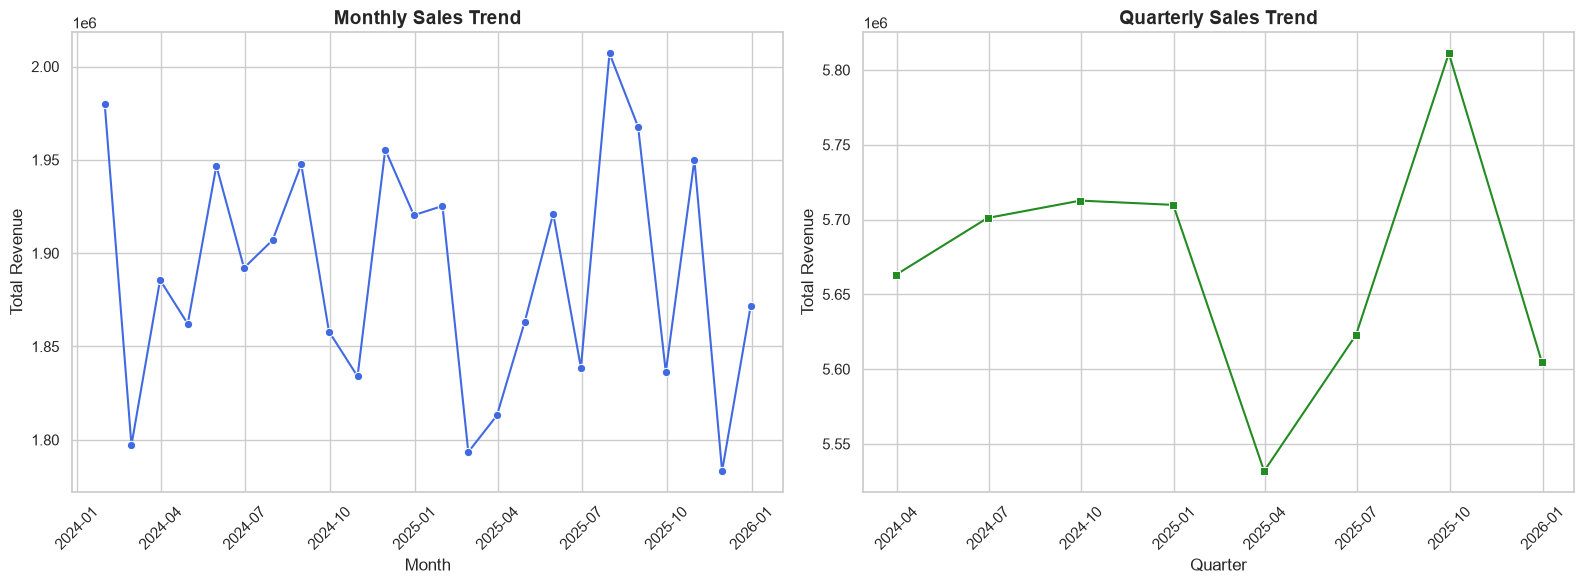

In [ ]:
# Time series analysis

# 1. Convert the date column to datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# 2. Set the date as the dataframe index 
df_time = df.set_index('transaction_date')

# 3. Resample data: Calculate total sales amount per Month ('ME') and Quarter ('QE')
monthly_sales = df_time['sales_amount'].resample('ME').sum().reset_index()
quarterly_sales = df_time['sales_amount'].resample('QE').sum().reset_index()

# 4. Set up the figure for subplots (1 row, 2 columns)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Monthly Sales Trend
sns.lineplot(data=monthly_sales, x='transaction_date', y='sales_amount', 
             marker='o', color='royalblue', ax=axes[0])
axes[0].set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Total Revenue', fontsize=12)
# Rotate x-axis labels for better readability
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Quarterly Sales Trend
sns.lineplot(data=quarterly_sales, x='transaction_date', y='sales_amount', 
             marker='s', color='forestgreen', ax=axes[1])
axes[1].set_title('Quarterly Sales Trend', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quarter', fontsize=12)
axes[1].set_ylabel('Total Revenue', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout and display
plt.tight_layout()
plt.show()
